In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Task 3 and 4_Loan_Data.csv')
df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10000 non-null  int64  
 1   credit_lines_outstanding  10000 non-null  int64  
 2   loan_amt_outstanding      10000 non-null  float64
 3   total_debt_outstanding    10000 non-null  float64
 4   income                    10000 non-null  float64
 5   years_employed            10000 non-null  int64  
 6   fico_score                10000 non-null  int64  
 7   default                   10000 non-null  int64  
dtypes: float64(3), int64(5)
memory usage: 625.1 KB


In [4]:
df.describe()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.974577e+06,1.461200,4159.677034,8718.916797,70039.901401,4.552800,637.557700,0.185100
std,2.293890e+06,1.743846,1421.399078,6627.164762,20072.214143,1.566862,60.657906,0.388398
min,1.000324e+06,0.000000,46.783973,31.652732,1000.000000,0.000000,408.000000,0.000000
25%,2.977661e+06,0.000000,3154.235371,4199.836020,56539.867903,3.000000,597.000000,0.000000
50%,4.989502e+06,1.000000,4052.377228,6732.407217,70085.826330,5.000000,638.000000,0.000000
75%,6.967210e+06,2.000000,5052.898103,11272.263740,83429.166133,6.000000,679.000000,0.000000
max,8.999789e+06,5.000000,10750.677810,43688.784100,148412.180500,10.000000,850.000000,1.000000


In [5]:
df['default'].value_counts(normalize = True)

default
0    0.8149
1    0.1851
Name: proportion, dtype: float64

Formula used to calsulate Estimated Loss

EL=PD×LGD×EAD
PD = probability of default (this is what your model predicts)
LGD = loss given default = 1−recovery rate ; 1−recovery rate = 1−0.10 = 0.90
EAD = exposure at default ≈ the outstanding loan amount

In [6]:
df.corr()['default'].sort_values(ascending = False)

default                     1.000000
credit_lines_outstanding    0.862815
total_debt_outstanding      0.758868
loan_amt_outstanding        0.098978
income                      0.016309
customer_id                 0.006927
years_employed             -0.284506
fico_score                 -0.324515
Name: default, dtype: float64

In [7]:
import seaborn as sns

<Axes: xlabel='default', ylabel='fico_score'>

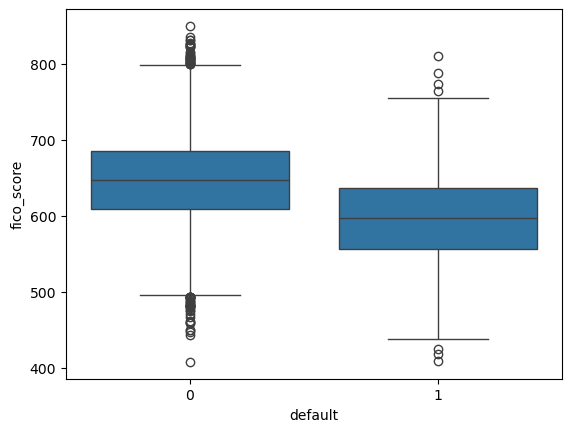

In [8]:
sns.boxplot(x='default', y='fico_score', data = df)

In [9]:
df.isnull().sum()

customer_id                 0
credit_lines_outstanding    0
loan_amt_outstanding        0
total_debt_outstanding      0
income                      0
years_employed              0
fico_score                  0
default                     0
dtype: int64

In [14]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['customer_id', 'default'])
y = df['default']
x_train, x_test, y_train, y_test = train_test_split (
    x,y, test_size = 0.2, random_state = 42, stratify = y)

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

logreg = LogisticRegression()
logreg.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
pd_pred = logreg.predict_proba(x_test_scaled)[:, 1] #probability of class 1

In [19]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators = 200, max_depth = 5, random_state = 42)
rf.fit(x_train, y_train)
pd_pred_rf = rf.predict_proba(x_test)[:, 1]

In [30]:
from sklearn.metrics import roc_auc_score, roc_curve, log_loss, brier_score_loss
auc = roc_auc_score(y_test, pd_pred)
print("AUC:", auc)

results = {
    "Logistic Regression":{
        "AUC": roc_auc_score(y_test, pd_pred),
        "LogLoss": log_loss(y_test, pd_pred),
        "brier": brier_score_loss(y_test, pd_pred)
    },
    "Random Forest":{
        "AUC": roc_auc_score(y_test, pd_pred_rf),
        "LogLoss": log_loss(y_test, pd_pred_rf),
        "Brier": brier_score_loss(y_test, pd_pred_rf)
    }
}
pd.DataFrame(results).T

AUC: 0.9999883933012768


,AUC,LogLoss,brier,Brier
Logistic Regression,0.999988,0.013069,0.002832,NaN
Random Forest,0.999597,0.037537,NaN,0.007832


In [36]:
def predict_expected_loss( borrower_feature: dict, model, scaler = None, recovery_rate = 0.10):
    x = pd.DataFrame([borrower_feature])
    if scaler is not None:
        x = scaler.transform(x)
    pd_estimate = model.predict_proba(x)[:,1][0]
    lgd = 1 - recovery_rate #loss given default (lgd)
    ead = borrower_feature['loan_amt_outstanding']#exposure at default (ead)
    expected_loss = pd_estimate*lgd*ead
    return expected_loss, pd_estimate

example_borrower = {
    'credit_lines_outstanding': 5,
    'loan_amt_outstanding': 4000,
    'total_debt_outstanding': 6000,
    'income': 3000,
    'years_employed': 4,
    'fico_score': 900
    }
el, pd_val = predict_expected_loss(example_borrower, logreg, scaler)
print(f"PD:{pd_val}, Expected Loss: ${el}")

PD:0.999096079788814, Expected Loss: $3596.7458872397306
